In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

E0000 00:00:1781016095.563921      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781016095.617460      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781016096.067921      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781016096.067958      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781016096.067961      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781016096.067963      58 computation_placer.cc:177] computation placer already registered. Please check linka

In [3]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()

x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [4]:
IMG_SIZE = 96

x_train = tf.image.resize(
    x_train,
    (IMG_SIZE, IMG_SIZE)
).numpy()

x_test = tf.image.resize(
    x_test,
    (IMG_SIZE, IMG_SIZE)
).numpy()

print(x_train.shape)
print(x_test.shape)

I0000 00:00:1781016115.397596      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781016115.400486      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


(50000, 96, 96, 3)
(10000, 96, 96, 3)


In [5]:
#loss function
import tensorflow as tf

class CustomLoss(tf.keras.losses.Loss):

    def __init__(
        self,
        lam=0.1,
        name="edge_aware_margin_loss"
    ):
        super().__init__(name=name)
        self.lam = lam

    def call(
        self,
        y_true,
        y_pred
    ):

        y_pred = tf.clip_by_value(
            y_pred,
            1e-7,
            1.0
        )

        ce = tf.keras.losses.categorical_crossentropy(
            y_true,
            y_pred
        )

        top2 = tf.math.top_k(
            y_pred,
            k=2
        ).values

        p1 = top2[:,0]
        p2 = top2[:,1]

        margin = p1 - p2

        margin_penalty = 1.0 - margin

        loss = ce + self.lam * margin_penalty

        return tf.reduce_mean(loss)

In [6]:
import numpy as np

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

labels = np.argmax(y_train, axis=1)

unique, counts = np.unique(
    labels,
    return_counts=True
)

for idx, count in zip(unique, counts):
    print(
        f"{class_names[idx]} : {count}"
    )

airplane : 5000
automobile : 5000
bird : 5000
cat : 5000
deer : 5000
dog : 5000
frog : 5000
horse : 5000
ship : 5000
truck : 5000


In [7]:
base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

outputs = Dense(
    10,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

model.summary()

/tmp/ipykernel_58/2794889684.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 48, 48, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 48, 48, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 48, 48, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 48, 48, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 24, 24, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 24, 24, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 24, 24, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 24, 24, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,239,114 (12.36 MB)

 Trainable params: 10,250 (40.04 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [8]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=CustomLoss(
        lam=0.1
    ),
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10


I0000 00:00:1781016149.060245     132 service.cc:152] XLA service 0x7fee800cb350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781016149.060295     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781016149.060302     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781016151.146426     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781016171.527546     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


352/352 ━━━━━━━━━━━━━━━━━━━━ 94s 166ms/step - accuracy: 0.3928 - loss: 2.2496 - val_accuracy: 0.6552 - val_loss: 1.0936
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 28s 80ms/step - accuracy: 0.6735 - loss: 1.0915 - val_accuracy: 0.7602 - val_loss: 0.7503
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 29s 81ms/step - accuracy: 0.7565 - loss: 0.8037 - val_accuracy: 0.8060 - val_loss: 0.6207
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 27s 77ms/step - accuracy: 0.8010 - loss: 0.6502 - val_accuracy: 0.8284 - val_loss: 0.5457
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.8305 - loss: 0.5440 - val_accuracy: 0.8444 - val_loss: 0.4962
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 28s 80ms/step - accuracy: 0.8491 - loss: 0.4775 - val_accuracy: 0.8570 - val_loss: 0.4597
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 28s 79ms/step - accuracy: 0.8694 - loss: 0.4109 - val_accuracy: 0.8656 - val_loss: 0.4355
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.8833 - loss: 0.3617 - val_accura

In [10]:
loss_after, acc = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Accuracy of the Fine-Tunned model:", acc)


Accuracy of the Fine-Tunned model: 0.8759999871253967


In [11]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred = model.predict(x_test)

y_pred_labels = y_pred.argmax(axis=1)
y_true_labels = y_test.argmax(axis=1)

precision = precision_score(
    y_true_labels,
    y_pred_labels,
    average='macro'
)

recall = recall_score(
    y_true_labels,
    y_pred_labels,
    average='macro'
)

f1 = f1_score(
    y_true_labels,
    y_pred_labels,
    average='macro'
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step
Precision : 0.8762
Recall    : 0.8760
F1 Score  : 0.8757


In [12]:
print(
    classification_report(
        y_true_labels,
        y_pred_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.86      0.90      0.88      1000
  automobile       0.92      0.94      0.93      1000
        bird       0.89      0.82      0.85      1000
         cat       0.79      0.77      0.78      1000
        deer       0.84      0.88      0.86      1000
         dog       0.83      0.82      0.83      1000
        frog       0.89      0.93      0.91      1000
       horse       0.91      0.89      0.90      1000
        ship       0.94      0.91      0.92      1000
       truck       0.91      0.92      0.91      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



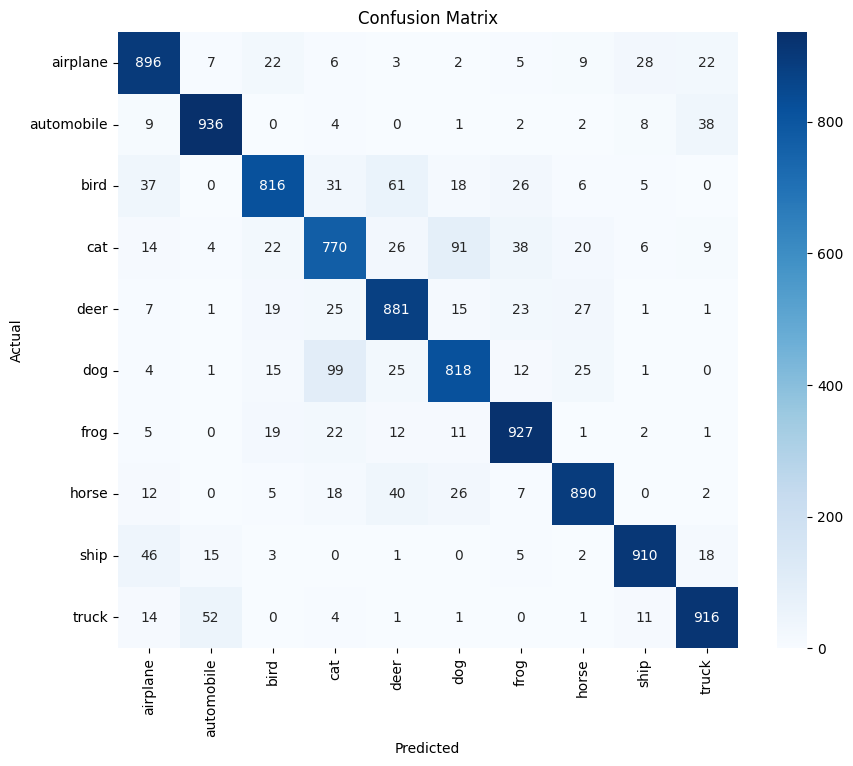

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true_labels,
    y_pred_labels
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
model.save("mobilenetv1_cifar10.h5")

import os

size_mb = os.path.getsize(
    "mobilenetv1_cifar10.h5"
)/(1024*1024)

print("Model Size:", size_mb, "MB")

Model Size: 37.24951171875 MB
